## Imports and definitions

In [ ]:
from deprecated import deprecated
from pathlib import Path
from datetime import datetime

from matplotlib import gridspec, pyplot as plt
import librosa
import numpy as np
from numpy import ndarray as array
from scipy.signal import argrelextrema, find_peaks_cwt, find_peaks
import soundfile as sf


from core.analysis.stems.common import Common

Defining `Song.class`:

In [ ]:
class Song():

    # ----- COMMON PROPERTIES -----
    def __init__(self):
        self._metadata = {}

    @property
    def path(self) -> str:
        """
        Returns the path to the file in the filesystem
        """
        return self._path

    # ----- FILE METADATA -----

    @property
    def metadata(self) -> object:
        return self._metadata

    def addMetadata(self, key: str, value) -> None:
        self._metadata[key] = value

Creating sample `Song` object:

In [3]:
mysong = Song()

# Required fields:
mysong.addMetadata('aio', {})
mysong.addMetadata('tinytag', {})

# > metadata['aio']['demucs'][stem]
mysong.metadata['aio']['demucs'] = {}
mysong.metadata['aio']['demucs']['bass'] = Path('/home/alvaro/Escritorio/SoundLight/SoundLight/demix/htdemucs/CamelPhat, Yannis, Foals - Hypercolour/bass.wav')

# > song.metadata['tinytag']['samplerate']
mysong.metadata['tinytag']['samplerate'] = 44100

# > song.metadata['tinytag']['bpm'][0]
mysong.metadata['tinytag']['bpm'] = ['122']

# > song.metadata['tinytag']['duration']
mysong.metadata['tinytag']['duration'] = 209.3422785206036

# > song.metadata['aio']['downbeats']
mysong.metadata['aio']['downbeats'] = [1.87,3.85,5.81,7.78,9.75,11.69,13.66,15.63,17.59,19.56,21.53,23.5,25.47,27.43,29.4,31.36,33.33,35.3,37.27,39.23,41.2,43.17,45.13,47.1,49.07,51.03,53.0,54.97,56.94,58.91,60.87,62.84,64.8,66.77,68.74,70.7,72.67,74.64,76.61,78.58,80.55,82.51,84.48,86.45,88.42,90.38,92.32,94.31,96.27,98.24,100.2,102.18,104.14,106.11,108.07,110.04,112.0,113.96,115.93,117.9,119.87,121.86,123.82,125.79,127.76,129.72,131.69,133.66,135.63,137.6,139.56,141.54,143.5,145.47,147.44,149.4,151.37,153.34,155.3,157.27,159.24,161.2,163.17,165.14,167.1,169.07,171.04,173.01,174.97,176.94,178.91,180.87,182.84,184.81,186.77,188.74,190.71,192.68,194.65,196.61,198.57,200.54]

# > song.metadata['aio']['segments']
mysong.metadata['aio']['segments'] = [
    {
      "start": 0.0,
      "end": 11.69,
      "label": "intro"
    },
    {
      "start": 11.69,
      "end": 27.43,
      "label": "verse"
    },
    {
      "start": 27.43,
      "end": 42.17,
      "label": "verse"
    },
    {
      "start": 42.17,
      "end": 58.9,
      "label": "chorus"
    },
    {
      "start": 58.9,
      "end": 74.64,
      "label": "chorus"
    },
    {
      "start": 74.64,
      "end": 90.38,
      "label": "bridge"
    },
    {
      "start": 90.38,
      "end": 120.84,
      "label": "verse"
    },
    {
      "start": 120.84,
      "end": 151.37,
      "label": "chorus"
    },
    {
      "start": 151.37,
      "end": 170.05,
      "label": "inst"
    },
    {
      "start": 170.05,
      "end": 184.81,
      "label": "chorus"
    },
    {
      "start": 184.81,
      "end": 200.54,
      "label": "outro"
    },
    {
      "start": 200.54,
      "end": 209.1,
      "label": "outro"
    }
  ]



# Stem Analysis: Bass
The bass will be analyzed finding the RMS peaks, and tracking them with a simple feature

## Step 1: Loading data
Loading file and computing attributes

In [4]:
# Load song data
attribs = Common.computeAttribs(mysong, 'bass')

song_data, sr = Common.load(attribs)  # array: Array with all samples
#Common.display(song_data)
print(f'Samples for song_data: {len(song_data)}')

Samples for song_data: 9221120


## Step 2: Configure RMS params for peak detection

As the different sections have different audio profiles, configuring RMS parameters is important for better recognition. The relevant parameters are:

- Frame Length: Number of samples over which the RMS will be calculated. A bigger number gives a smoother curve with less features.

- Hop Length: Number of samples that the window advances in each step. A bigger number reduces the resolution. If hop length is lower than the frame length, overlap occurs.

For bass, a bigger frame length is better, as it removes fake peaks. For hop length, a 4th of the frame length seems appropiate.

In [5]:
bass_rms_params: dict[str, int] = {'frame_length': 8192, 'hop_length': 2048}
rms_data: array = Common.getRMS(song_data, bass_rms_params)
#Common.display(rms_data, title=f"frame_length = {bass_rms_params['frame_length']}, hop_length = {bass_rms_params['hop_length']}")

We scale the RMS from 0 to 1 for ease of thresholding later

[INFO] at display: Visualizing data...
[SUCC] at display: Finished visualizing.


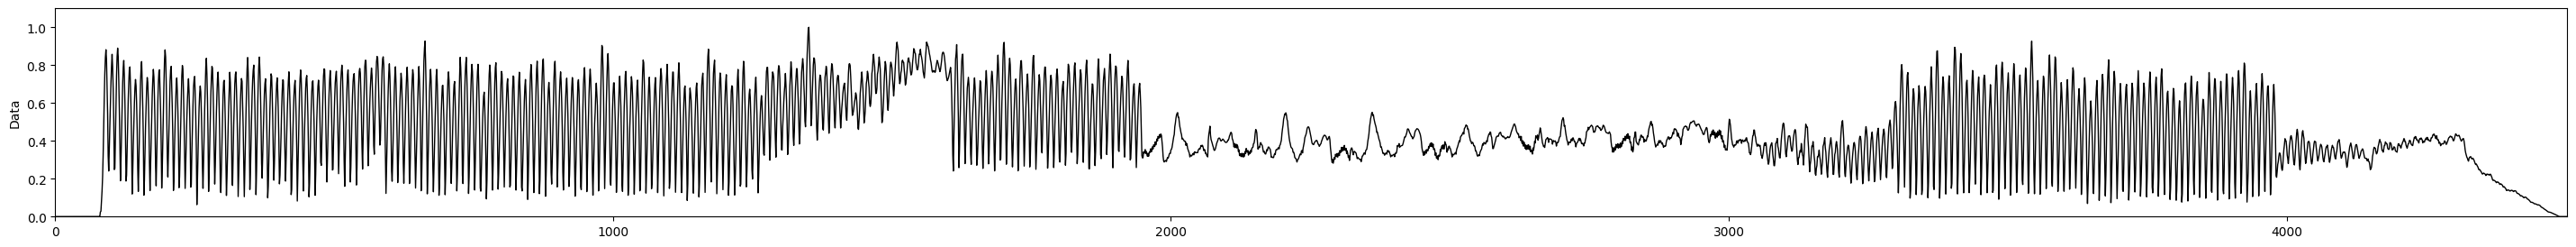

In [6]:
rms_data = Common.scale(rms_data)
Common.display(rms_data)

## Step A3: Divide song in beats

### Step A3.1
To divide the song in beats, we need the downbeat indexes for the sample to divide. For that, we need to convert the timestamps in seconds to sample indexes.

In [7]:
downbeat_indexes = Common.timestampToIndexOf(rms_data, attribs['downbeats'], attribs['track_length'])

In [8]:
beats, beats_i = Common.split(rms_data, downbeat_indexes)

# Get section start indexes
all_sections_i = []
for section in beats_i:
    all_sections_i.append(section[0])
    
#Common.display(rms_data, downbeats_i = all_sections_i)

### Step A3.2: Get peaks for a beat
To more accurately calculate peaks, we will treat each section separately.


In [9]:
# Select sections
oneSection = beats[10]
oneSection_i = beats_i[10]

someSections = np.concatenate(beats[10:20])
someSections_i = np.concatenate(beats_i[10:20])

allSections = np.concatenate(beats)
allSections_i = np.concatenate(beats_i)

In [10]:
peaks_i, valleys_i = Common.getPeakIndexes(allSections)

### Step A3.3: Calculate beat thresholds


In [11]:
# Calculating the high threshold
threshold_high = np.mean(allSections[peaks_i]) 
all_filters = {}
all_filters['high'] = threshold_high
all_filters['low'] = 0

# Filtering low peaks:
peaks_i: array = Common.filterThresholds(allSections, all_filters, peaks_i)

In [12]:
sections = {}
sections['start_i'] = downbeat_indexes

# Common.display(data=allSections, peaks_i=peaks_i, valleys_i=None, thresholds=thresholds, section_dict=section, figsize=(48, 6))

## Step B3: Divide song in phrases

To divide the song in phrases, we employ the AIO results.

In [13]:
phrase_starts = [i['start'] for i in attribs['phrases']]
phrase_indexes = Common.timestampToIndexOf(rms_data, phrase_starts, attribs['track_length'])
phrases, phrases_i = Common.split(rms_data, phrase_indexes)

Now, we process each phrase independently:

In [14]:
all_phrases = []
all_phrases_indexes = []
all_peaks_i = []
all_filters =[]

filter_str: str = 'hybrid'


In [15]:
for p_i in range(len(phrases)):
    
    phrase = phrases[p_i]
    phrase_i = phrases_i[p_i]

    # We get the peaks from the phrase samples
    p_peak_i, p_valley_i = Common.getPeakIndexes(phrase)
    match filter_str:
        case 'threshold':
            # We calculate the threshold as above the mean of the samples
            th_mean = np.mean(phrase)
            filter_d = {'xmin': phrase_i[0],'xmax': phrase_i[-1],'high': float(th_mean)}

            # We filter the peaks with this threshold
            p_peak_i = Common.filterThresholds(phrase, filter_d, p_peak_i)
        case 'reg_line':
            # We calculate the regression line for the phrase samples
            reg_line = np.poly1d(np.polyfit([i+phrase_i[0]  for i in range(len(phrase))], phrase, 1))

            def filter(arr:array, i: int):
                return arr[i] >= reg_line(i)
            # Filter all below regression line
            p_peak_i = Common.filterWith(data=phrase, data_i=p_peak_i, filter=filter)
            filter_d = {'reg_line': reg_line}
        case 'hybrid':
            # We calculate the threshold as above the mean of the samples
            th_mean = np.mean(phrase)
            filter_d = {'xmin': phrase_i[0],'xmax': phrase_i[-1],'high': float(th_mean)}

            # We filter the peaks with this threshold
            p_peak_i = Common.filterThresholds(phrase, filter_d, p_peak_i)

            # We calculate the regression line for the phrase samples
            reg_line = np.poly1d(np.polyfit([i for i in range(len(phrase))], phrase, 1))
            def filter(arr:array, i: int):
                return arr[i] >= reg_line(i)
            # Filter the phrase samples with the regression line
            p_peak_i = Common.filterWith(data=phrase, data_i=p_peak_i, filter=filter)

            # Adjust regression line with correct indexes
            reg_line = np.poly1d(np.polyfit(phrase_i, phrase, 1))
            filter_d['reg_line'] = reg_line
        case _:
            pass

    # Adjusting peak offset
    p_peak_i += phrase_i[0]

    # Save results
    all_phrases.append(phrase)
    all_phrases_indexes.append(phrase_i[0])
    all_peaks_i.append(p_peak_i)
    all_filters.append(filter_d.copy())

We can now render the output:

[INFO] at display: Visualizing data...
[INFO] at display: Plotting peaks...
[SUCC] at display: Finished visualizing.


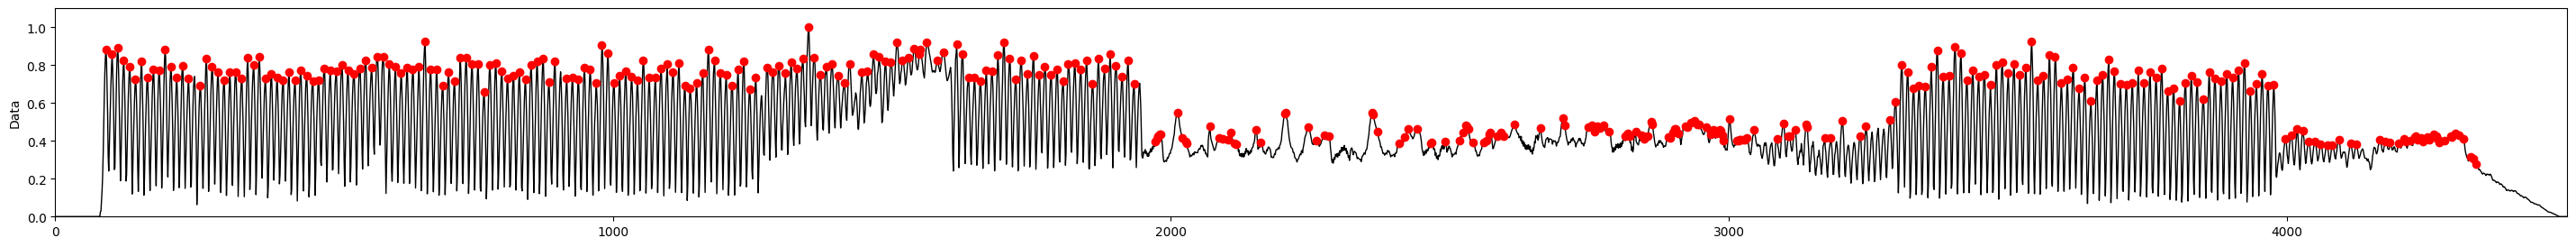

In [16]:
#Common.display(data=np.concatenate(all_phrases), peaks_i=np.concatenate(all_peaks_i), thresholds=all_filters, section_i=all_phrases_indexes, reg_line=True)
Common.display(data=rms_data, peaks_i=np.concatenate(all_peaks_i))

## Step 4: Get peaks
For the bass stem, a sectioned bass filtering might not be wanted.

[INFO] at display: Visualizing data...
[INFO] at display: Plotting peaks...
[INFO] at display: Plotting sections...
[SUCC] at display: Finished visualizing.


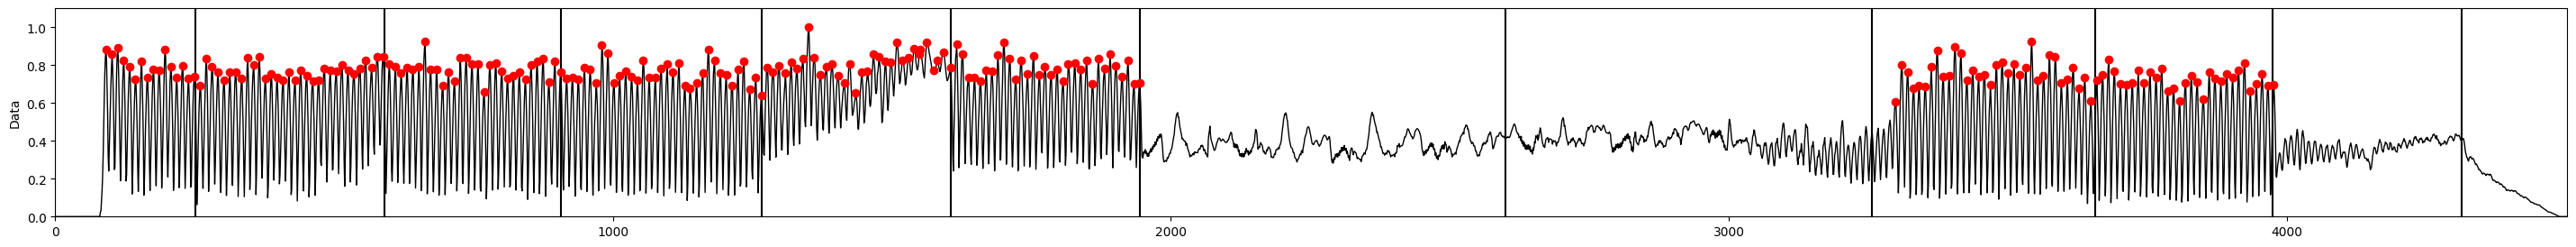

In [17]:
filter = {}
# TODO: Programatically calculate this value
filter['high'] = np.mean(rms_data) * 1.25

peaks_i, valleys_i = Common.getPeakIndexes(rms_data)

peaks_i = Common.filterThresholds(rms_data, filter, peaks_i)

Common.display(rms_data, peaks_i, section_i=phrase_indexes)

In [18]:
Common.sonify(data=rms_data, sr=attribs['sr'], peaks=peaks_i)

In [19]:
# Converting RMS samples to song samples
adjusting_factor = int(0.1*attribs['sr'])
peaks_i = np.asarray([i * (len(song_data)//len(rms_data)) + adjusting_factor for i in peaks_i])
# Common.sonify(data=song_data, sr=attribs['sr'], peaks=peaks_i)